In [2]:
import numpy as np
import pandas as pd
from pandas_datareader import data as wb
import matplotlib.pyplot as plt
import yfinance as yf
import datetime
import math as m
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
%matplotlib inline

In [3]:
assets = ["AAPL", "MSFT", "JPM", "JNJ", "XOM", "^GSPC"]
data = yf.download(assets, start="2020-01-01", end="2025-01-01")

[*********************100%***********************]  6 of 6 completed


In [4]:
print("--- Data Overview ---")
print(data.head())
print(data.info())

--- Data Overview ---
Price           Close                                                 \
Ticker           AAPL         JNJ         JPM        MSFT        XOM   
Date                                                                   
2020-01-02  72.400528  122.638245  118.430321  152.158401  53.306412   
2020-01-03  71.696625  121.218346  116.867477  150.263748  52.877853   
2020-01-06  72.267929  121.067162  116.774506  150.652161  53.283848   
2020-01-07  71.928062  121.806488  114.789322  149.278580  52.847782   
2020-01-08  73.085098  121.789680  115.684799  151.656326  52.050816   

Price                         High                                      ...  \
Ticker            ^GSPC       AAPL         JNJ         JPM        MSFT  ...   
Date                                                                    ...   
2020-01-02  3257.850098  72.460791  122.680255  118.438723  152.262607  ...   
2020-01-03  3234.850098  72.455943  122.134117  117.619335  151.523684  ...   
2020-0

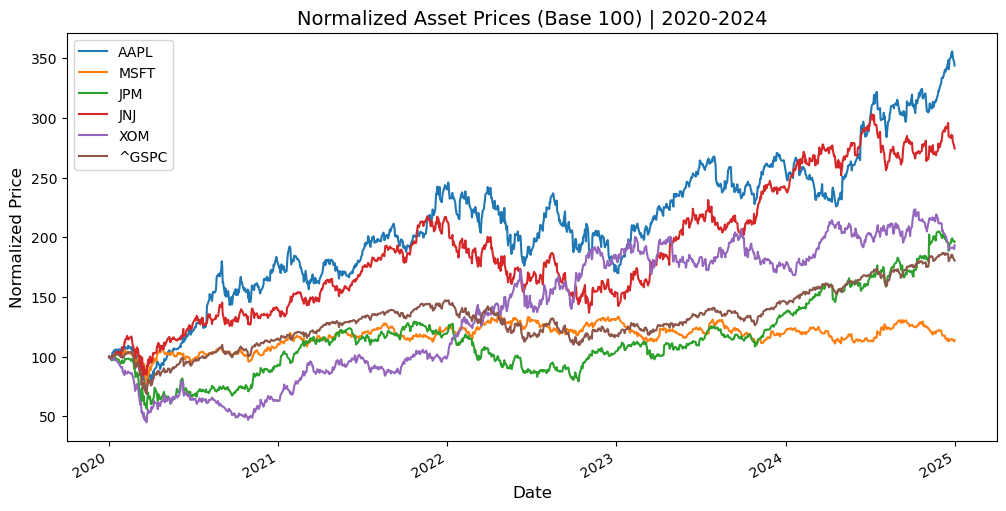

In [6]:
normalization = (data["Close"] / data["Close"].iloc[0]) * 100
normalization.plot(figsize=(12, 6))
plt.title("Normalized Asset Prices (Base 100) | 2020-2024", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Normalized Price", fontsize=12)
plt.legend(assets)
plt.show()

In [7]:
log_return = np.log(data["Close"] / data["Close"].shift(1))

In [8]:
simple_returns = data["Close"].pct_change().dropna()

In [9]:
annual_returns = simple_returns.mean() * 250

In [15]:
print("\n--- Annual Returns (Asset) ---")
print(str(round(annual_returns*100,2))+"%")


--- Annual Returns (Asset) ---
Ticker
AAPL     29.55
JNJ       4.48
JPM      18.64
MSFT     24.70
XOM      18.98
^GSPC    14.02
dtype: float64%


In [12]:
stocks = ["AAPL", "MSFT", "JPM", "JNJ", "XOM"]

In [16]:
stock_annual_returns = annual_returns[stocks]

In [19]:
# Portfolio A: Equal-weight
equal_weights = np.array([0.20, 0.20, 0.20, 0.20, 0.20])

In [20]:
# Portfolio B: Conviction-based
conviction_weights = np.array([0.20, 0.10, 0.10, 0.50, 0.10])

In [21]:
portfolio_a_return = np.dot(equal_weights, stock_annual_returns)
portfolio_b_return = np.dot(conviction_weights, stock_annual_returns)

In [22]:
benchmark_return = annual_returns["^GSPC"]